In [20]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from OceanDataStore import OceanDataCatalog 
from nemo_cookbook import NEMODataTree  


In [21]:
catalog = OceanDataCatalog(catalog_name="noc-model-stac")
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')
ds1 = catalog.open_dataset(id=catalog.Items[1].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [22]:
catalog.search(collection='noc-npd-era5', item_name='domain_cfg')
config = (catalog.open_dataset(id=catalog.Items[0].id)).isel(t = 0, drop = True)
config = config.rename({'z': 'nav_lev'})


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/domain/domain_cfg
              Title: eORCA1 ERA5v1 NPD domain/domain_cfg Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean model domain_cfg variables.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/domain/domain_cfg
              Title: eORCA025 ERA5v1 NPD domain/domain_cfg Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 NPD global ocean model domain_cfg variables.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca12-era5v1/gn/domain/domain_cfg
              Title: eORCA12 ERA5v1 NPD domain/domain_cfg Icechunk repository
              Description: Icechunk

In [23]:
datasets = {"parent": {"domain": config, "gridT": ds1}}
dt = NEMODataTree.from_datasets(datasets = datasets)
dataset_full = dt['/gridT']

mask = (dataset_full['gphit'] >= 0) & (dataset_full['gphit'] <= 80) & (dataset_full['glamt'] >= -85 ) & (dataset_full['glamt'] <= 0)
subset = dataset_full.where(mask, drop=True)

AttributeError: 'NEMODataTree' object has no attribute 'where'

In [24]:
dataset_full['tos_con']

<xarray.DataArray 'tos_con' (time_counter: 420, j: 331, i: 360)> Size: 200MB
dask.array<getitem, shape=(420, 331, 360), dtype=float32, chunksize=(1, 331, 360), chunktype=numpy.ndarray>
Coordinates:
  * time_counter   (time_counter) datetime64[ns] 3kB 1990-01-16T12:00:00 ... ...
  * j              (j) int64 3kB 1 2 3 4 5 6 7 8 ... 325 326 327 328 329 330 331
  * i              (i) int64 3kB 1 2 3 4 5 6 7 8 ... 354 355 356 357 358 359 360
    time_centered  (time_counter) datetime64[ns] 3kB dask.array<chunksize=(1,), meta=np.ndarray>
    gphit          (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    glamt          (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
Attributes:
    standard_name:       sea_surface_temperature
    long_name:           sea_surface_conservative_temperature
    units:               degC
    online_operation:    average
    interval_operation:  3600 s
    interval_write:      1 month
    cell_methods:        time: mean (interval: 3600 s)

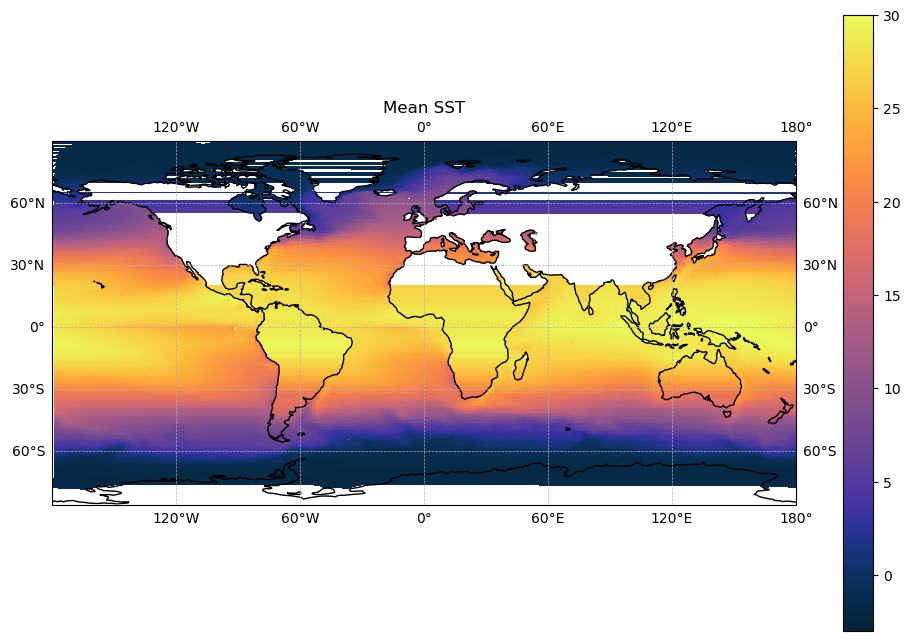

In [27]:
fig, ax = plt.subplots(figsize = (12, 8), subplot_kw = {'projection': ccrs.PlateCarree()})
mean_tos = dataset_full['tos_con'].mean(dim = 'time_counter')
im = ax.pcolormesh(dataset_full['glamt'], dataset_full['gphit'], mean_tos, cmap = cmocean.cm.thermal, transform = ccrs.PlateCarree(), vmin = -3, vmax = 30)
cl = ax.coastlines()
gl = ax.gridlines(draw_labels = True, linewidth = 0.5, linestyle = '--')
ax.set_title('Mean SST')

plt.colorbar(im, ax = ax)
plt.show()

In [38]:
ds1

<xarray.Dataset> Size: 143GB
Dimensions:                (time_counter: 420, y: 1206, x: 1440, axis_nbounds: 2)
Coordinates:
  * time_counter           (time_counter) datetime64[ns] 3kB 1990-01-16T12:00...
    nav_lat                (y, x) float64 14MB dask.array<chunksize=(1206, 1440), meta=np.ndarray>
    nav_lon                (y, x) float64 14MB dask.array<chunksize=(1206, 1440), meta=np.ndarray>
    time_centered          (time_counter) datetime64[ns] 3kB dask.array<chunksize=(1,), meta=np.ndarray>
Dimensions without coordinates: y, x, axis_nbounds
Data variables: (12/51)
    berg_latent_heat_flux  (time_counter, y, x) float32 3GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    evs                    (time_counter, y, x) float32 3GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    hfevapds               (time_counter, y, x) float32 3GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    ficeberg               (time_counter, y, x) float32 3GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    friver                 (time_counter, y, x) float32 3GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    fsitherm               (time_counter, y, x) float32 3GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    ...                     ...
    time_counter_bounds    (time_counter, axis_nbounds) datetime64[ns] 7kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    sowflisf               (time_counter, y, x) float32 3GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    tossq_con              (time_counter, y, x) float32 3GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    ttrd_qns_li            (time_counter, y, x) float32 3GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    zossq                  (time_counter, y, x) float32 3GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    zos                    (time_counter, y, x) float32 3GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>